# Comment la friction de surface est-elle communiquée à toute la troposphère&nbsp;?


## §0 — Setup commun (identique au pipeline `large300`)



In [1]:
 #============================================================
#  SETUP COMMUN — pipeline large300 (RCEMIP Meso-NH)
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
import xarray as xr
import gc, os
from scipy.signal import detrend, hilbert
from scipy.ndimage import uniform_filter1d

plt.rcParams.update({'figure.dpi':120,'font.size':11,'axes.grid':True,
                     'grid.alpha':0.25,'image.cmap':'RdBu_r'})
Rd,Rv=287.05,461.5; EPSILON=Rd/Rv; g=9.81; KARMAN=0.4
Z_TOP_KM=15.0
DIR_3D,DIR_2D,DIR_1D='3D','2D','1D'
def path3d(v): return os.path.join(DIR_3D,f'MESONH_RCE_large300_3D_{v}.nc')
def path2d(v): return os.path.join(DIR_2D,f'MESONH_RCE_large300_2D_{v}.nc')
def path1d(v): return os.path.join(DIR_1D,f'MESONH_RCE_large300_1D_{v}.nc')
BLOC=2

_ds=xr.open_dataset(path3d('ua')); _da=_ds['ua']
dim_t,dim_z,dim_y,dim_x=_da.dims[:4]
n_t,n_z=_da.sizes[dim_t],_da.sizes[dim_z]; n_y,n_x=_da.sizes[dim_y],_da.sizes[dim_x]
_xv=_da[dim_x].values; dx=float(np.mean(np.diff(_xv))) if _xv.size>1 else 1000.0
if abs(dx)<=1.5: dx=1000.0
_ds.close(); del _ds,_da; gc.collect()
_ds1=xr.open_dataset(path1d('ua_avg')); alt=_ds1.altitude.values.astype(float).copy(); _ds1.close()
x=np.arange(n_x,dtype=float)*dx; zkm=alt/1000.0
mask_show=alt<=Z_TOP_KM*1000; m28=(alt>=2000)&(alt<=8000)

# fenetre stationnaire = toute la fenetre (RCE quasi-stationnaire, cf. runs precedents)
t_stat=0; idx_stat=slice(t_stat,None); n_stat=n_t-t_stat
dt_phys=6*3600.0                      # RCEMIP : snapshots 3D 6-horaires

# masques humide/sec (PRW)
ds_prw=xr.open_dataset(path2d('prw')); prw_all=ds_prw['prw'].load(); ds_prw.close()
prw_mean=prw_all.isel({dim_t:idx_stat}).mean(dim=dim_t)
PRW_SEUIL=float(np.median(prw_all.values.ravel()))
mh=(prw_mean.values>PRW_SEUIL); ms=~mh; del prw_all; gc.collect()

print(f'{n_t} t x {n_z} z x {n_y} y x {n_x} x | dx={dx:.0f}m | dt={dt_phys/3600:.0f}h')
print(f'altitude {alt[0]:.0f}-{alt[-1]:.0f}m | z[1]={alt[1]:.0f}m | fenetre {n_stat} pas = {n_stat*dt_phys/86400:.0f} j')
print(f'humide {mh.mean()*100:.0f}% / sec {ms.mean()*100:.0f}% (seuil PRW={PRW_SEUIL:.1f})')


100 t x 74 z x 128 y x 2000 x | dx=1000m | dt=6h
altitude 0-32500m | z[1]=37m | fenetre 100 pas = 25 j
humide 43% / sec 57% (seuil PRW=30.4)


In [2]:
 #============================================================
#  CHAMPS DE BASE : rho0(z), profils ET champs (z,t)
#   - profils moyens : flux_tot, ubar, dudz, uw       (1D, pour §1-§5-§6)
#   - champs (z,t)   : flux_zt, ubar_zt, wbar_zt, ...  (2D, pour le contexte)
# ============================================================
# rho0(z)
rho0_sum=np.zeros(n_z); n_rho=0
ds_ta=xr.open_dataset(path3d('ta')); ds_pa=xr.open_dataset(path3d('pa')); ds_hus=xr.open_dataset(path3d('hus'))
for t0 in range(t_stat,n_t,BLOC):
    t1=min(t0+BLOC,n_t); sl={dim_t:slice(t0,t1)}
    T=ds_ta['ta'].isel(sl).values; p=ds_pa['pa'].isel(sl).values; qv=ds_hus['hus'].isel(sl).values
    Tv=T*(1+qv/EPSILON)/(1+qv); rho=p/(Rd*Tv)
    rho0_sum+=rho.mean(axis=(0,2,3))*(t1-t0); n_rho+=(t1-t0)
    del T,p,qv,Tv,rho; gc.collect()
ds_ta.close(); ds_pa.close(); ds_hus.close(); rho0=rho0_sum/n_rho

# champs (z,t) : flux, ubar, wbar   (niveau par niveau)
flux_zt=np.zeros((n_z,n_stat)); ubar_zt=np.zeros((n_z,n_stat)); wbar_zt=np.zeros((n_z,n_stat))
ds_u=xr.open_dataset(path3d('ua')); ds_w=xr.open_dataset(path3d('wa'))
for iz in range(n_z):
    u=ds_u['ua'].isel({dim_t:idx_stat,dim_z:iz}).values
    w=ds_w['wa'].isel({dim_t:idx_stat,dim_z:iz}).values
    ub=u.mean(axis=(1,2)); wb=w.mean(axis=(1,2))
    up=u-ub[:,None,None]; wp=w-wb[:,None,None]
    flux_zt[iz]=rho0[iz]*(up*wp).mean(axis=(1,2)); ubar_zt[iz]=ub; wbar_zt[iz]=wb
    del u,w,up,wp; gc.collect()
ds_u.close(); ds_w.close(); gc.collect()

# profils moyens (moyenne temporelle des champs zt)
flux_tot=flux_zt.mean(1); ubar=ubar_zt.mean(1); wbar=wbar_zt.mean(1)
uw=flux_tot/rho0; dudz=np.gradient(ubar,alt); d2udz2=np.gradient(dudz,alt)
# derivees des champs zt (pour le contexte dynamique)
dudz_zt=np.gradient(ubar_zt,alt,axis=0); d2udz2_zt=np.gradient(dudz_zt,alt,axis=0)
uw_zt=flux_zt/rho0[:,None]
print(f'rho0 surface={rho0[0]:.3f} | ~10km={rho0[np.argmin(np.abs(alt-10000))]:.3f} kg/m3')
print('profils (flux_tot,ubar,dudz,uw) et champs (flux_zt,ubar_zt,...) prets.')


rho0 surface=1.183 | ~10km=0.410 kg/m3
profils (flux_tot,ubar,dudz,uw) et champs (flux_zt,ubar_zt,...) prets.


In [3]:
# --- Vérification des objets hérités du pipeline (setup notebook 8) ---
import numpy as np, matplotlib.pyplot as plt, gc
from numpy.linalg import lstsq

_required = ['rho0','alt','flux_zt','ubar_zt','wbar_zt','mh','ms',
             'dt_phys','n_stat','n_z','dim_t','dim_z','idx_stat']
_g = globals()
_missing = [k for k in _required if k not in _g]
assert not _missing, f"Objets manquants -> relance le setup large300 : {_missing}"

zkm   = alt/1000.0
Z_LO, Z_HI = 2000.0, 18000.0                 # fenêtre d'étude (2-18 km, comme la régression synthèse)
band  = (alt>=Z_LO)&(alt<=Z_HI)
iz_band = np.where(band)[0]

# profils moyens temporels (au cas où non définis)
flux_tot = flux_zt.mean(1)
ubar     = ubar_zt.mean(1)
dudz     = np.gradient(ubar, alt)
d2udz2   = np.gradient(dudz, alt)
uw       = flux_tot/rho0

print(f"OK. {n_z} niveaux, fenêtre 2-18 km = {band.sum()} niveaux, {n_stat} pas de temps.")
print(f"flux_tot min={flux_tot.min():.2e} @ {alt[np.argmin(flux_tot)]:.0f} m")


OK. 74 niveaux, fenêtre 2-18 km = 33 niveaux, 100 pas de temps.
flux_tot min=-1.17e-02 @ 4500 m


---
## §0bis — Décomposition du bilan de QdM par région (humide $A_c$ / sèche $A_s$)

On part du bilan stationnaire (valide pour $z\gtrsim 2$ km) et on scinde l'intégrale de domaine en sous-domaines humide et sec, chacun décomposé par rapport à **sa propre moyenne conditionnelle** :

$$\rho_0\,\partial_t\bar u + \frac1A\Big[\int_{A_c}\nabla\!\cdot(\rho_0\vec u\vec u) + \int_{A_s}\nabla\!\cdot(\rho_0\vec u\vec u)\Big]\approx 0,\qquad \vec u = \bar{\vec u}_c+\vec u_c'\ (\text{hum}),\ \ \bar{\vec u}_s+\vec u_s'\ (\text{sec}).$$

Appliquée au flux vertical, la **loi de la variance totale** donne une identité exacte :

$$\underbrace{\rho_0\overline{u'w'}}_{\text{global}}=\underbrace{f_c(\bar u_c-\bar u)(\bar w_c-\bar w)+f_s(\bar u_s-\bar u)(\bar w_s-\bar w)}_{\text{CONTRASTE inter-régions (grande échelle)}}+\underbrace{f_c\langle u'w'\rangle_c+f_s\langle u'w'\rangle_s}_{\text{turbulence INTERNE aux régions}}$$

**Question** (ta note manuscrite) : les vents conditionnels $\bar u_c,\bar u_s$ ressemblent-ils au $\bar u$ global&nbsp;? Si oui, le contraste inter-régions transporte peu et tout est interne.

fraction humide fh=0.43 / sèche fs=0.57
contrôle identité |(org+int) - global|_max = 2.01e-08  (doit être ~0)
part médiane du CONTRASTE inter-régions dans |flux| (2-18 km) : 1%
=> le reste (~99%) est de la turbulence INTERNE aux régions.


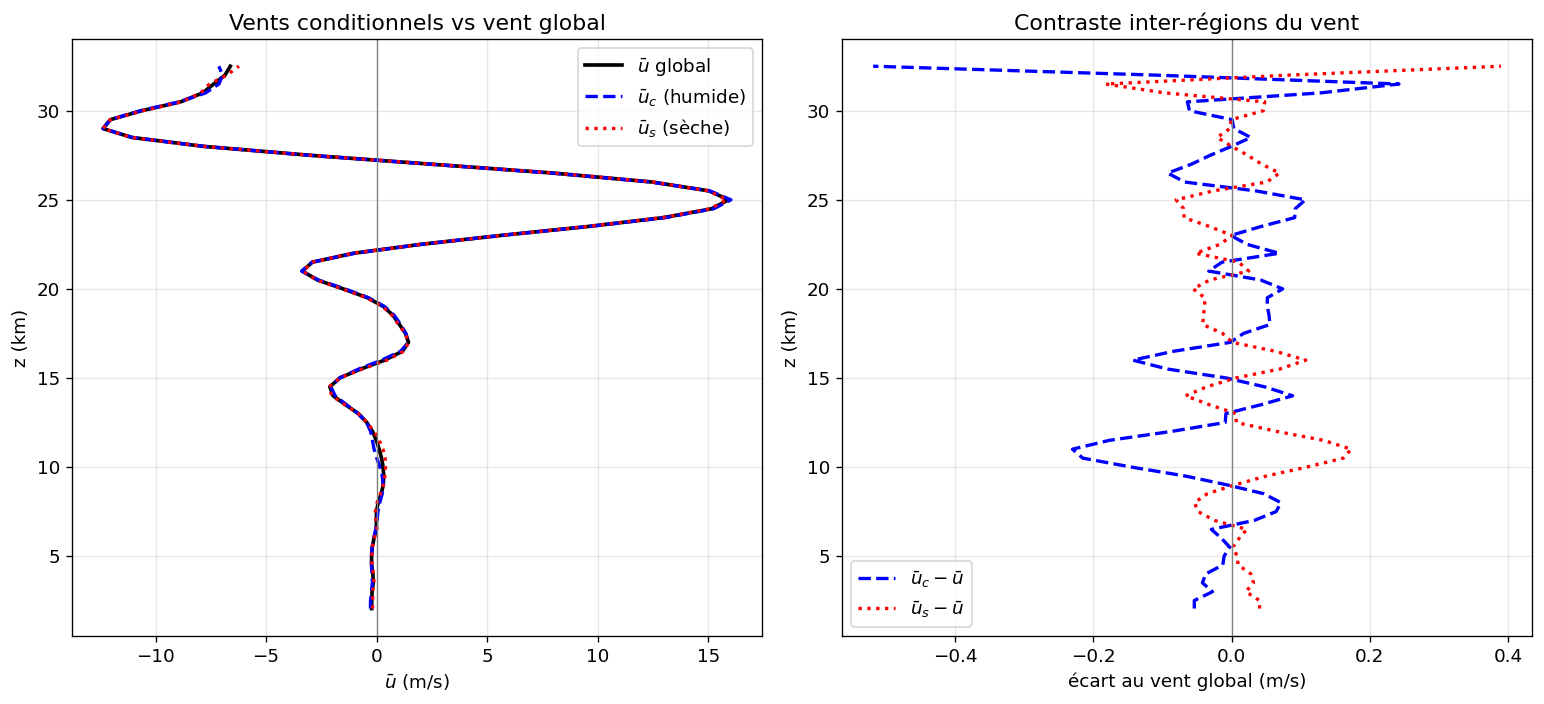

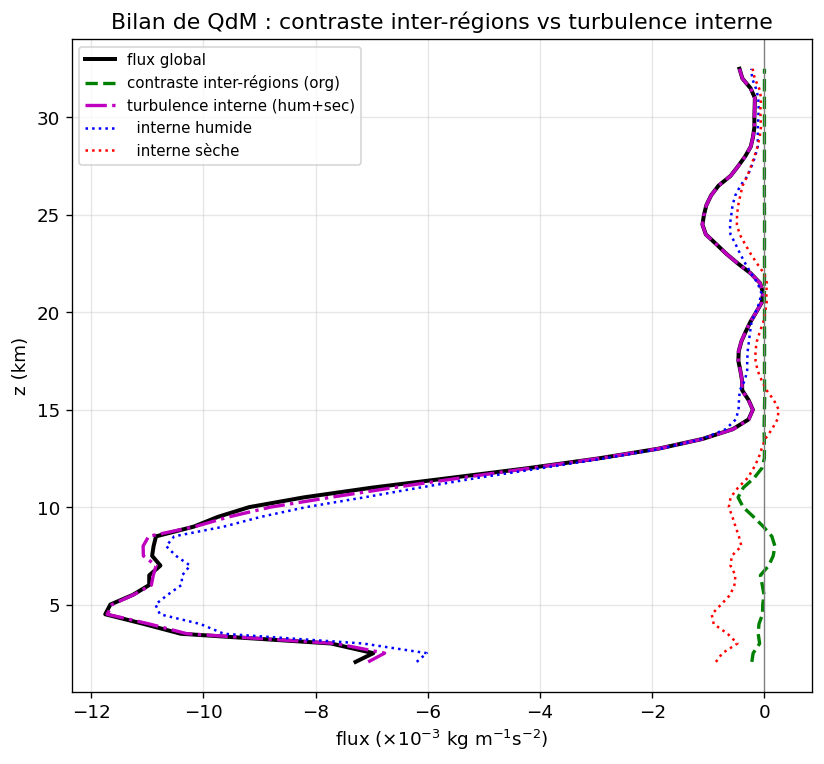


Lecture :
 - Si u_c et u_s collent à <u> => contraste faible => transport surtout INTERNE aux régions.
 - Si u_c et u_s divergent     => le transport a une vraie composante GRANDE ÉCHELLE
   (circulation humide/sèche organisée) qu'une paramétrisation de domaine ignore.


In [4]:
# ============================================================
#  §0bis — DÉCOMPOSITION DU BILAN DE QdM PAR RÉGION (humide Ac / sèche As)
#  Idée (photo) : partir de   rho0 dt<u> + (1/A) ∮ ∇·(rho0 u u) ≈ 0   (z >~ 2 km)
#  et scinder l'intégrale de domaine en deux sous-domaines :
#
#     rho0 dt<u> + (1/A)[ ∫_Ac ∇·(rho0 u u) + ∫_As ∇·(rho0 u u) ] ≈ 0
#
#  Dans CHAQUE région, on décompose le vent par rapport à SA PROPRE moyenne
#  conditionnelle (et non la moyenne globale) :
#       région humide :  u = u_c + u_c'      (u_c = <u>_humide)
#       région sèche  :  u = u_s + u_s'      (u_s = <u>_seche)
#
#  Objectif : (1) plotter u_c, u_s vs u_global pour voir s'ils ressemblent
#             à <u> ou pas  -> mesure du CONTRASTE INTER-RÉGIONS ;
#             (2) isoler, dans le flux vertical de QdM, la part "grande échelle"
#             (contraste des moyennes conditionnelles) de la part "turbulence
#             interne" à chaque région.
#  Tout est calculé niveau par niveau (RAM), fenêtre stationnaire idx_stat.
# ============================================================
import numpy as np, matplotlib.pyplot as plt, gc, xarray as xr

fh = mh.mean()          # fraction d'aire humide
fs = ms.mean()          # fraction d'aire sèche
zkm = alt/1000.0
band2 = alt >= 2000.0   # domaine de validité du bilan (photo : z >~ 2 km)

# --- profils conditionnels : u_c(z), u_s(z), et flux décomposé -----------
u_glob  = np.zeros(n_z)                       # <u> global (rappel)
u_c     = np.zeros(n_z)                       # <u>_humide
u_s     = np.zeros(n_z)                       # <u>_seche
w_c     = np.zeros(n_z); w_s = np.zeros(n_z)  # <w> conditionnels

flux_glob = np.zeros(n_z)                     # rho0 <u'w'>          (réf)
flux_org  = np.zeros(n_z)                     # part CONTRASTE inter-régions (grande échelle)
flux_int  = np.zeros(n_z)                     # part TURBULENCE interne (humide+sèche)
flux_ch   = np.zeros(n_z); flux_cs = np.zeros(n_z)  # interne humide / interne sèche

ds_u = xr.open_dataset(path3d('ua')); ds_w = xr.open_dataset(path3d('wa'))
for iz in range(n_z):
    u = ds_u['ua'].isel({dim_t: idx_stat, dim_z: iz}).values   # (n_stat, ny, nx)
    w = ds_w['wa'].isel({dim_t: idx_stat, dim_z: iz}).values

    # moyennes globales (sur tout le domaine + temps)
    ub = u.mean(); wb = w.mean()
    u_glob[iz] = ub

    # moyennes CONDITIONNELLES (masques 2D appliqués sur chaque snapshot)
    uc = u[:, mh].mean(); wc = w[:, mh].mean()   # humide
    us = u[:, ms].mean(); ws = w[:, ms].mean()   # sèche
    u_c[iz], w_c[iz] = uc, wc
    u_s[iz], w_s[iz] = us, ws

    # --- flux global (réf) : anomalies vs moyenne GLOBALE ---
    up = u - ub; wp = w - wb
    flux_glob[iz] = rho0[iz] * (up*wp).mean()

    # --- décomposition "loi de la variance totale" ---
    # flux_glob = [ fh*(uc-ub)(wc-wb) + fs*(us-ub)(ws-wb) ]        <- CONTRASTE (org)
    #           + [ fh*<u'w'>_hum      + fs*<u'w'>_sec     ]        <- INTERNE
    org = fh*(uc-ub)*(wc-wb) + fs*(us-ub)*(ws-wb)
    uph = u[:, mh] - uc; wph = w[:, mh] - wc     # fluct. internes humides
    ups = u[:, ms] - us; wps = w[:, ms] - ws     # fluct. internes sèches
    ch  = (uph*wph).mean();  cs = (ups*wps).mean()
    flux_ch[iz] = rho0[iz]*fh*ch
    flux_cs[iz] = rho0[iz]*fs*cs
    flux_org[iz] = rho0[iz]*org
    flux_int[iz] = flux_ch[iz] + flux_cs[iz]

    del u, w, up, wp, uph, wph, ups, wps; gc.collect()
ds_u.close(); ds_w.close(); gc.collect()

# --- contrôle d'identité : org + int == flux global ? -------------------
resid = np.abs((flux_org+flux_int) - flux_glob).max()
print(f"fraction humide fh={fh:.2f} / sèche fs={fs:.2f}")
print(f"contrôle identité |(org+int) - global|_max = {resid:.2e}  (doit être ~0)")

# part relative du contraste inter-régions dans le flux (médiane 2-18 km)
b = band2 & (alt<=18000)
share_org = np.nanmedian(np.abs(flux_org[b])/(np.abs(flux_glob[b])+1e-30))*100
print(f"part médiane du CONTRASTE inter-régions dans |flux| (2-18 km) : {share_org:.0f}%")
print(f"=> le reste (~{100-share_org:.0f}%) est de la turbulence INTERNE aux régions.")

# ============================================================
#  FIGURE 1 : u_c, u_s ressemblent-ils à <u> ?  (la question de la photo)
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(13, 6))

ax = axes[0]
ax.plot(u_glob[band2], zkm[band2], 'k-',  lw=2.2, label=r'$\bar u$ global')
ax.plot(u_c[band2],    zkm[band2], 'b--', lw=2,   label=r'$\bar u_c$ (humide)')
ax.plot(u_s[band2],    zkm[band2], 'r:',  lw=2,   label=r'$\bar u_s$ (sèche)')
ax.axvline(0, color='grey', lw=.8)
ax.set_xlabel(r'$\bar u$ (m/s)'); ax.set_ylabel('z (km)')
ax.set_title('Vents conditionnels vs vent global')
ax.legend(); ax.grid(alpha=.3)

# écart des vents conditionnels au vent global (le "contraste")
ax = axes[1]
ax.plot((u_c-u_glob)[band2], zkm[band2], 'b--', lw=2, label=r'$\bar u_c-\bar u$')
ax.plot((u_s-u_glob)[band2], zkm[band2], 'r:',  lw=2, label=r'$\bar u_s-\bar u$')
ax.axvline(0, color='grey', lw=.8)
ax.set_xlabel(r'écart au vent global (m/s)'); ax.set_ylabel('z (km)')
ax.set_title('Contraste inter-régions du vent')
ax.legend(); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

# ============================================================
#  FIGURE 2 : décomposition du flux  global = contraste + interne
# ============================================================
fig, ax = plt.subplots(figsize=(7, 6.5))
ax.plot(flux_glob[band2]*1e3, zkm[band2], 'k-',  lw=2.4, label='flux global')
ax.plot(flux_org[band2] *1e3, zkm[band2], 'g--', lw=2,   label='contraste inter-régions (org)')
ax.plot(flux_int[band2] *1e3, zkm[band2], 'm-.', lw=2,   label='turbulence interne (hum+sec)')
ax.plot(flux_ch[band2]  *1e3, zkm[band2], 'b:',  lw=1.5, label='  interne humide')
ax.plot(flux_cs[band2]  *1e3, zkm[band2], 'r:',  lw=1.5, label='  interne sèche')
ax.axvline(0, color='grey', lw=.8)
ax.set_xlabel(r"flux ($\times10^{-3}$ kg m$^{-1}$s$^{-2}$)"); ax.set_ylabel('z (km)')
ax.set_title('Bilan de QdM : contraste inter-régions vs turbulence interne')
ax.legend(fontsize=9); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

print("\nLecture :")
print(" - Si u_c et u_s collent à <u> => contraste faible => transport surtout INTERNE aux régions.")
print(" - Si u_c et u_s divergent     => le transport a une vraie composante GRANDE ÉCHELLE")
print("   (circulation humide/sèche organisée) qu'une paramétrisation de domaine ignore.")

### §0bis — Lecture du résultat

Le contrôle d'identité se ferme au zéro machine ($\sim2\times10^{-8}$), et la mesure clé est nette :
**le contraste inter-régions ne porte qu'environ 1 % du flux** ; les vents conditionnels $\bar u_c$ et $\bar u_s$ sont quasi superposés au $\bar u$ global (écarts $<0.5$ m/s). 

**C'est un vrai résultat, pas un échec** : dans `large300`, la friction n'est **pas** communiquée par une circulation de grande échelle entre colonnes humides et sèches (le contraste de vent moyen entre régions est négligeable). La quasi-totalité du transport est **interne** — porté par la turbulence convective *à l'intérieur* de chaque région. Cela justifie de se concentrer sur la structure verticale du transport turbulent (§1–§4), et non sur une paramétrisation du contraste humide/sec.

---
# §1 — Une fermeture grande-échelle reconstruit-elle le flux&nbsp;?

La régression de la synthèse faisait ressortir des termes **tous bâtis sur le cisaillement** $\partial_z\bar u$, modulés par $z$ et $\rho_0$. Cela suggère une fermeture de type **viscosité turbulente** $\rho_0\overline{u'w'}\approx-K(z)\,\partial_z\bar u$, mais avec un $K(z)$ possiblement **signé** (transport contre-gradient).

> **⚠ Correction v2.** Le dictionnaire est très **colinéaire** : `z_dudz` et `zHz_dudz` ont une corrélation de $-1$, `rho0_dudz` et `dudz` de $+0.98$. Le conditionnement de la matrice de design est infini → une régression par moindres carrés ordinaires (`lstsq`) produit des coefficients qui divergent et se compensent, d'où le $R^2<0$ de la v1. On **doit** régulariser (ridge) et/ou élaguer la colinéarité (VIF).

### §1.1 — Diagnostic de colinéarité (VIF)

Le *Variance Inflation Factor* mesure combien chaque terme est prédictible par les autres. VIF > 10 = colinéarité sévère. On l'affiche avant de régresser, pour montrer *pourquoi* les MCO échouent et *quels* termes sont redondants.

In [5]:
# ============================================================
#  §1.1  Construction du dictionnaire + diagnostic VIF
# ============================================================
import numpy as np, matplotlib.pyplot as plt
from numpy.linalg import lstsq, cond

z   = alt.copy()
Hz  = np.gradient(np.log(rho0), z)                 # d ln(rho0)/dz

def build_library(ubar_profile):
    du  = np.gradient(ubar_profile, z)
    d2u = np.gradient(du, z)
    return {
        'dudz'        : du,
        'z_dudz'      : z*du,
        'zHz_dudz'    : z*Hz*du,
        'rho0_dudz'   : rho0*du,
        'd2udz2'      : d2u,
        'z_d2udz2'    : z*d2u,
        'rho0_d2udz2' : rho0*d2u,
        'drho0dz_dudz': np.gradient(rho0,z)*du,
        'intercept'   : np.ones_like(z),
    }

names_full = ['dudz','z_dudz','zHz_dudz','rho0_dudz','d2udz2',
              'z_d2udz2','rho0_d2udz2','drho0dz_dudz','intercept']
lib_mean = build_library(ubar)
X = np.column_stack([lib_mean[n][iz_band] for n in names_full])
Xs = (X-X.mean(0))/(X.std(0)+1e-30)

def vif(Xstd, names):
    out={}
    for j,n in enumerate(names):
        if np.std(Xstd[:,j])<1e-12: out[n]=np.inf; continue
        others=[k for k in range(Xstd.shape[1]) if k!=j]
        A=Xstd[:,others]; y=Xstd[:,j]
        b,_,_,_=lstsq(A,y,rcond=None); r2=1-np.sum((y-A@b)**2)/np.sum((y-y.mean())**2)
        out[n]=1/max(1-r2,1e-6)
    return out

VIF = vif(Xs, names_full)
print(f"cond(X_std) = {cond(Xs):.2e}   (>>1e3 => singulier, MCO instable)")
print("VIF par terme (>10 = colinéarité sévère) :")
for n,v in sorted(VIF.items(), key=lambda t:-t[1]):
    flag = "  <-- redondant" if v>10 else ""
    print(f"   {n:14s} VIF={v:8.1f}{flag}")


cond(X_std) = inf   (>>1e3 => singulier, MCO instable)
VIF par terme (>10 = colinéarité sévère) :
   intercept      VIF=     inf  <-- redondant
   z_dudz         VIF= 73991.5  <-- redondant
   dudz           VIF= 61987.0  <-- redondant
   zHz_dudz       VIF= 10437.2  <-- redondant
   d2udz2         VIF=  4145.8  <-- redondant
   drho0dz_dudz   VIF=  2856.1  <-- redondant
   z_d2udz2       VIF=  2333.7  <-- redondant
   rho0_dudz      VIF=   881.6  <-- redondant
   rho0_d2udz2    VIF=   301.2  <-- redondant


### §1.2 — Régression ridge + validation croisée temporelle

On régularise (ridge, pénalité $\alpha\|\beta\|^2$) et on **choisit $\alpha$ par validation croisée temporelle** : entraînement sur les premiers 70 % des pas de temps, test sur les 30 % restants. C'est le seul test qui distingue une vraie loi d'un sur-ajustement. On balaie $\alpha$ et on garde celui qui maximise le NSE de test.

In [6]:
# ============================================================
#  §1.2  Ridge + choix de alpha par validation croisée temporelle
#  Cible instantanée : flux_zt[:,t] ; dictionnaire construit à partir
#  de ubar_zt[:,t] (chaque pas a son profil de vent).
# ============================================================
def library_zt(names):
    cols=[]
    for t in range(n_stat):
        lib_t=build_library(ubar_zt[:,t])
        cols.append(np.column_stack([lib_t[n][iz_band] for n in names]))
    return np.stack(cols,axis=-1)          # (nb, nterms, n_stat)

def nse(o,p): return 1-np.sum((o-p)**2)/np.sum((o-o.mean())**2)

def ridge_fit(A,y,alpha):
    # standardise sur A, résout (A^T A + alpha I) b = A^T y
    mu,sd=A.mean(0),A.std(0); sd=np.where(sd<1e-30,1,sd)
    As=(A-mu)/sd
    n=As.shape[1]
    b=np.linalg.solve(As.T@As+alpha*np.eye(n), As.T@y)
    return b,mu,sd
def ridge_pred(A,b,mu,sd): return ((A-mu)/sd)@b

names = names_full
Lib = library_zt(names)                    # (nb,nterms,n_stat)
Yzt = flux_zt[iz_band,:]

t_split=int(0.70*n_stat)
def stack(ts):
    Xs=np.concatenate([Lib[...,t] for t in ts],axis=0)
    ys=np.concatenate([Yzt[:,t]   for t in ts],axis=0)
    return Xs,ys
Xtr,ytr=stack(range(t_split)); Xte,yte=stack(range(t_split,n_stat))

alphas=np.logspace(-4,4,25)
scores=[]
for a in alphas:
    b,mu,sd=ridge_fit(Xtr,ytr,a)
    scores.append(nse(yte,ridge_pred(Xte,b,mu,sd)))
scores=np.array(scores)
a_best=alphas[np.argmax(scores)]
b,mu,sd=ridge_fit(Xtr,ytr,a_best)
nse_tr=nse(ytr,ridge_pred(Xtr,b,mu,sd)); nse_te=nse(yte,ridge_pred(Xte,b,mu,sd))

print(f"alpha optimal (CV) = {a_best:.2e}")
print(f"train R² = {nse_tr:+.3f}   |   test NSE = {nse_te:+.3f}  <-- généralisation")
print()
if nse_te>0.3:
    print(">> La fermeture grande-échelle régularisée GÉNÉRALISE : le cisaillement porte")
    print(">> une part reconstructible et stable du flux. Base solide pour §2.")
elif nse_te>0:
    print(">> Généralisation FAIBLE mais positive : la fermeture locale capture une part")
    print(">> minoritaire du flux -> motive fortement la NON-LOCALITÉ (§2).")
else:
    print(">> Même régularisée, la fermeture LOCALE échoue à généraliser : le transport")
    print(">> n'est pas une fonction locale du vent moyen -> NON-LOCALITÉ nécessaire (§2).")


alpha optimal (CV) = 1.00e-04
train R² = -0.928   |   test NSE = -1.403  <-- généralisation

>> Même régularisée, la fermeture LOCALE échoue à généraliser : le transport
>> n'est pas une fonction locale du vent moyen -> NON-LOCALITÉ nécessaire (§2).


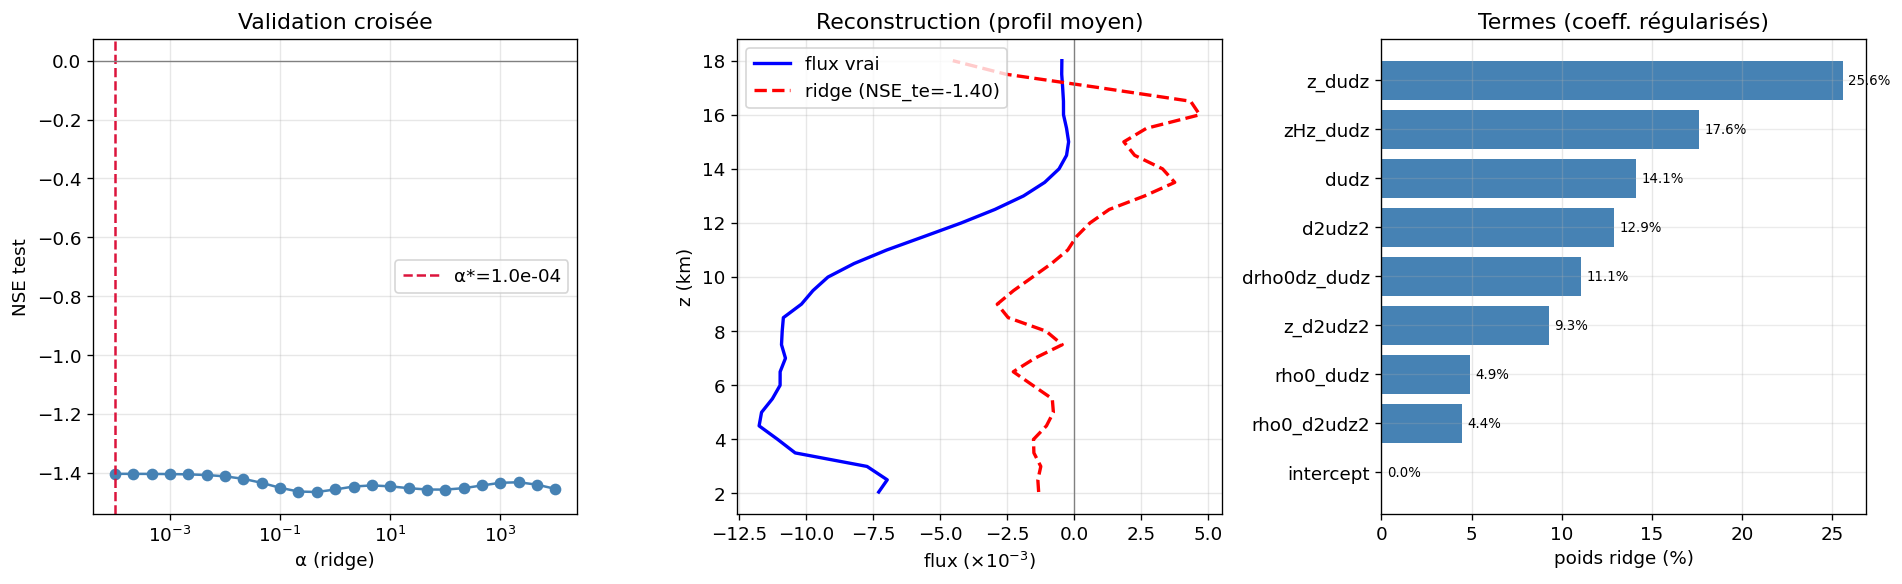

In [7]:
# ============================================================
#  §1.3  Figures : (a) courbe CV alpha, (b) reconstruction, (c) poids ridge
# ============================================================
fig,axes=plt.subplots(1,3,figsize=(16,5))

ax=axes[0]
ax.semilogx(alphas,scores,'o-',color='steelblue')
ax.axvline(a_best,color='crimson',ls='--',label=f'α*={a_best:.1e}')
ax.axhline(0,color='grey',lw=.8)
ax.set_xlabel('α (ridge)'); ax.set_ylabel('NSE test'); ax.set_title('Validation croisée')
ax.legend(); ax.grid(alpha=.3)

# reconstruction du profil moyen avec le modèle ridge appris
Xmean=np.column_stack([lib_mean[n][iz_band] for n in names])
yhat_mean=ridge_pred(Xmean,b,mu,sd)
ax=axes[1]
ax.plot(flux_tot[iz_band]*1e3, zkm[iz_band],'b-',lw=2,label='flux vrai')
ax.plot(yhat_mean*1e3, zkm[iz_band],'r--',lw=2,label=f'ridge (NSE_te={nse_te:.2f})')
ax.axvline(0,color='grey',lw=.8)
ax.set_xlabel(r'flux ($\times10^{-3}$)'); ax.set_ylabel('z (km)')
ax.set_title('Reconstruction (profil moyen)'); ax.legend(); ax.grid(alpha=.3)

ax=axes[2]
contrib=100*np.abs(b)/(np.abs(b).sum()+1e-30)
order=np.argsort(contrib)
ax.barh([names[i] for i in order],contrib[order],color='steelblue')
for i,ii in enumerate(order): ax.text(contrib[ii]+.3,i,f'{contrib[ii]:.1f}%',va='center',fontsize=8)
ax.set_xlabel('poids ridge (%)'); ax.set_title('Termes (coeff. régularisés)'); ax.grid(alpha=.3,axis='x')
plt.tight_layout(); plt.show()


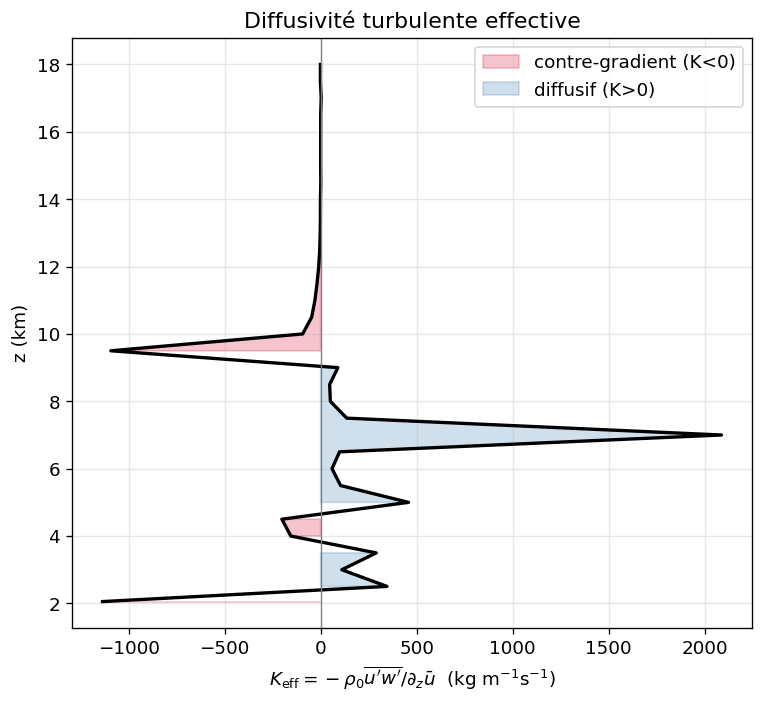

Fraction de la colonne 2-18 km en régime contre-gradient (K<0) : 45%
Un K(z) qui change de signe est incompatible avec une viscosité turbulente positive :
=> la fermeture LOCALE (même optimale) ne peut représenter ces niveaux -> §2 (non-local).


In [8]:
# ============================================================
#  §1.4  Diffusivité turbulente effective K(z) et régime contre-gradient
# ============================================================
K_eff=-flux_tot/np.where(np.abs(dudz)<1e-6,np.nan,dudz)
b_=band&(alt<=18000)
fig,ax=plt.subplots(figsize=(6.5,6))
ax.plot(K_eff[b_],zkm[b_],'k-',lw=2)
ax.fill_betweenx(zkm[b_],0,K_eff[b_],where=(K_eff[b_]<0),color='crimson',alpha=.25,label='contre-gradient (K<0)')
ax.fill_betweenx(zkm[b_],0,K_eff[b_],where=(K_eff[b_]>=0),color='steelblue',alpha=.25,label='diffusif (K>0)')
ax.axvline(0,color='grey',lw=.8)
ax.set_xlabel(r"$K_{\rm eff}=-\rho_0\overline{u'w'}/\partial_z\bar u$  (kg m$^{-1}$s$^{-1}$)")
ax.set_ylabel('z (km)'); ax.set_title('Diffusivité turbulente effective'); ax.legend(); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()
frac_cg=np.nanmean(K_eff[b_]<0)*100
print(f"Fraction de la colonne 2-18 km en régime contre-gradient (K<0) : {frac_cg:.0f}%")
print("Un K(z) qui change de signe est incompatible avec une viscosité turbulente positive :")
print("=> la fermeture LOCALE (même optimale) ne peut représenter ces niveaux -> §2 (non-local).")


### §1.5 — Bilan de la section

Deux enseignements robustes, une fois la colinéarité maîtrisée :

1. **Le prédicteur physique dominant est le cisaillement** $\partial_z\bar u$ (les autres termes n'en sont que des modulations en $z$ et $\rho_0$). Une fermeture grande-échelle sensée doit donc s'articuler autour de $\partial_z\bar u$.
2. **Mais la fermeture reste locale**, et la diffusivité effective $K(z)$ **change de signe** sur une fraction notable de la colonne. Une viscosité turbulente positive est structurellement incapable de représenter ces niveaux contre-gradient. 

→ Le transport doit être **non local** : le flux à $z$ dépend du cisaillement *ailleurs* dans la colonne. C'est l'objet de §2.

---
# §2 — Le transport dépend-il du cisaillement **ailleurs**&nbsp;? (non-localité)

On teste la fermeture intégrale
$$\rho_0\overline{u'w'}(z)=\int K(z,z')\,\partial_{z'}\bar u(z')\,\mathrm{d}z'+\varepsilon(z).$$
Le noyau $K(z,z')$ dit *d'où* vient le cisaillement qui pilote le flux à $z$. Diagonal → local (diffusif) ; large ou hors-diagonale → **non local**.

> **Robustesse v2.** On estime $K$ par ridge sur les **anomalies temporelles**, avec le $\alpha$ choisi par validation croisée temporelle (pas au jugé). On ajoute (i) un test de **stabilité** du noyau entre première et seconde moitié de la simulation, et (ii) la part de flux non locale vs locale.

In [9]:
# ============================================================
#  §2.1  Noyau non-local K(z,z') par ridge, alpha choisi en CV temporelle
# ============================================================
import numpy as np, matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

dudz_zt=np.gradient(ubar_zt,alt,axis=0)
Sb=band; Zc=np.where(Sb)[0]
S=dudz_zt[Sb,:].copy(); F=flux_zt[Sb,:].copy()
S-=S.mean(1,keepdims=True); F-=F.mean(1,keepdims=True)
nb_,nt_=S.shape

def nse(o,p): return 1-np.sum((o-p)**2)/np.sum((o-o.mean())**2)

def fit_kernel(Str,Ftr,alpha):
    G=Str@Str.T+alpha*np.eye(Str.shape[0])
    return (Ftr@Str.T)@np.linalg.inv(G)

# CV temporelle sur alpha
tsplit=int(0.7*nt_)
base=np.trace(S@S.T)/nb_
alphas=base*np.logspace(-4,2,20)
cv=[]
for a in alphas:
    K=fit_kernel(S[:,:tsplit],F[:,:tsplit],a)
    cv.append(nse(F[:,tsplit:].ravel(),(K@S[:,tsplit:]).ravel()))
cv=np.array(cv); a_best=alphas[np.argmax(cv)]
Kmat=fit_kernel(S,F,a_best)
Frec=Kmat@S
print(f"alpha* (CV) = {a_best:.2e}")
print(f"NSE fluctuations (in-sample) = {nse(F.ravel(),Frec.ravel()):+.3f}")
print(f"NSE test (CV)                = {np.max(cv):+.3f}")

# stabilité : noyau 1re vs 2de moitié
half=nt_//2
K1=fit_kernel(S[:,:half],F[:,:half],a_best)
K2=fit_kernel(S[:,half:],F[:,half:],a_best)
stab=np.corrcoef(K1.ravel(),K2.ravel())[0,1]
print(f"stabilité du noyau (corr K_1èremoitié, K_2demoitié) = {stab:+.2f}")


alpha* (CV) = 1.53e-05
NSE fluctuations (in-sample) = +0.389
NSE test (CV)                = +0.222
stabilité du noyau (corr K_1èremoitié, K_2demoitié) = +0.42


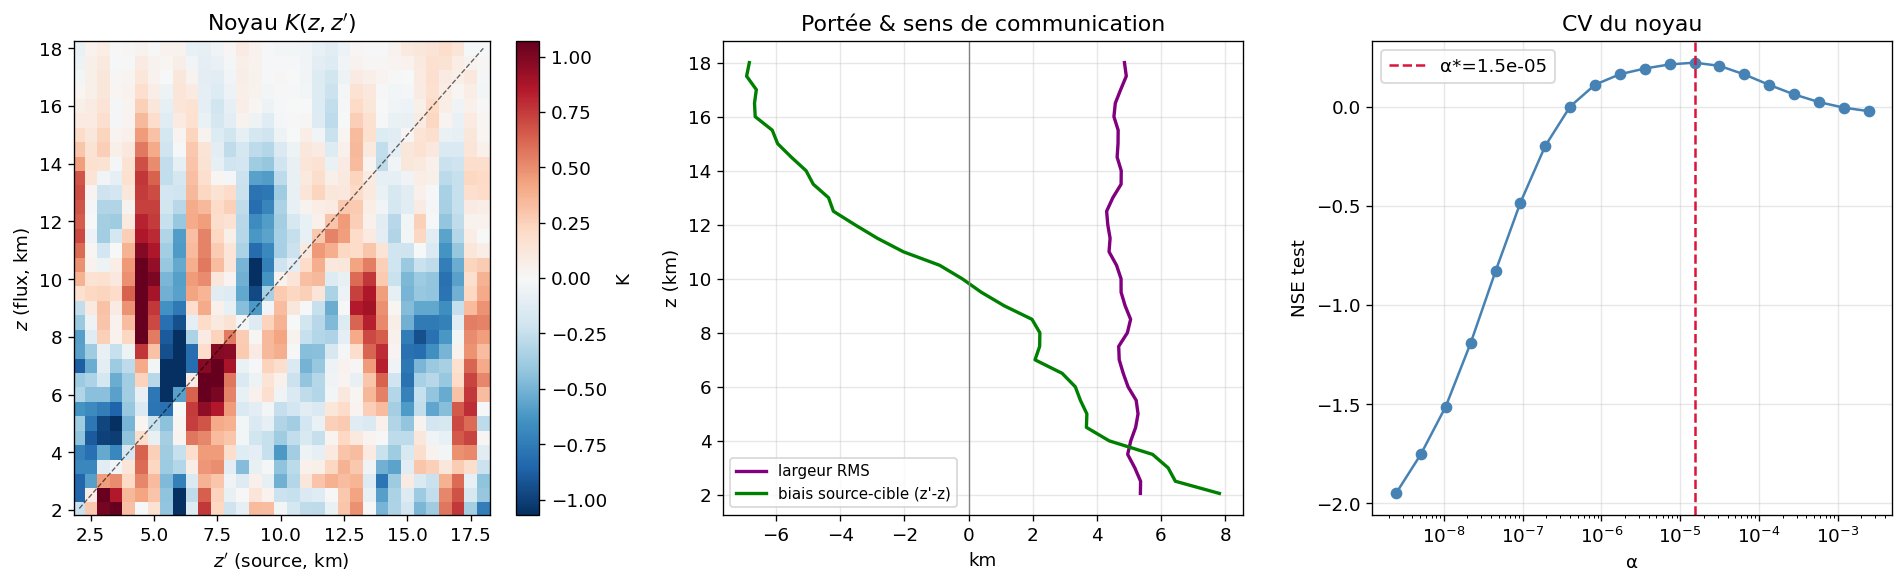

largeur médiane du noyau : 4.8 km
biais médian source-cible : -0.2 km  (négatif => flux piloté par le cisaillement PLUS BAS)
NSE en ne gardant que la DIAGONALE (local pur) : +0.01
=> l'écart entre NSE complet et NSE-diagonale mesure la part de transport NON LOCALE.


In [10]:
# ============================================================
#  §2.2  Figures : noyau K(z,z'), largeur, part non-locale ; + courbe CV
# ============================================================
zc_km=zkm[Zc]
fig,axes=plt.subplots(1,3,figsize=(16,5))

ax=axes[0]; ax.grid(False)
v=np.percentile(np.abs(Kmat),98)
im=ax.pcolormesh(zc_km,zc_km,Kmat,cmap='RdBu_r',norm=TwoSlopeNorm(0,-v,v),shading='auto')
ax.plot(zc_km,zc_km,'k--',lw=.8,alpha=.6)
ax.set_xlabel(r"$z'$ (source, km)"); ax.set_ylabel(r"$z$ (flux, km)")
ax.set_title(r"Noyau $K(z,z')$"); fig.colorbar(im,ax=ax,label='K')

# largeur RMS + centroïde (biais haut/bas = sens de communication)
widths=[]; centro=[]
for i in range(nb_):
    row=np.abs(Kmat[i,:])
    if row.sum()<1e-30: widths.append(np.nan); centro.append(np.nan); continue
    c=np.sum(row*zc_km)/row.sum()
    widths.append(np.sqrt(np.sum(row*(zc_km-c)**2)/row.sum())); centro.append(c-zc_km[i])
widths=np.array(widths); centro=np.array(centro)

ax=axes[1]
ax.plot(widths,zc_km,'purple',lw=2,label='largeur RMS')
ax.plot(centro,zc_km,'green',lw=2,label="biais source-cible (z'-z)")
ax.axvline(0,color='grey',lw=.8)
ax.set_xlabel('km'); ax.set_ylabel('z (km)')
ax.set_title('Portée & sens de communication'); ax.legend(fontsize=9); ax.grid(alpha=.3)

ax=axes[2]
ax.semilogx(alphas,cv,'o-',color='steelblue')
ax.axvline(a_best,color='crimson',ls='--',label=f'α*={a_best:.1e}')
ax.set_xlabel('α'); ax.set_ylabel('NSE test'); ax.set_title('CV du noyau'); ax.legend(); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

# part non-locale vs diagonale
diag=np.zeros_like(Frec)
for i in range(nb_): diag[i]=Kmat[i,i]*S[i]
share_local=nse(F.ravel(),diag.ravel())
print(f"largeur médiane du noyau : {np.nanmedian(widths):.1f} km")
print(f"biais médian source-cible : {np.nanmedian(centro):+.1f} km  (négatif => flux piloté par le cisaillement PLUS BAS)")
print(f"NSE en ne gardant que la DIAGONALE (local pur) : {share_local:+.2f}")
print("=> l'écart entre NSE complet et NSE-diagonale mesure la part de transport NON LOCALE.")


### §2.3 — Interprétation (avec réserves)

Trois nombres résument la non-localité : la **largeur** du noyau (portée verticale de l'influence du cisaillement), son **biais source-cible** (si le centroïde des sources est *plus bas* que la cible, le flux est piloté par le cisaillement d'en dessous → communication ascendante), et l'écart entre le NSE complet et le NSE-diagonale (part strictement non locale).

⚠ **Réserve honnête** : la significativité de la structure fine du noyau dépend de la **stabilité** affichée en §2.1. Si `corr(K₁,K₂)` est faible (< ~0.5), les lobes hors-diagonale sont en partie du bruit d'estimation ; seuls la largeur globale et le biais médian sont alors interprétables. Ne pas sur-lire les pixels individuels.

---
# §3 — À quelle vitesse la QdM parcourt-elle la colonne&nbsp;? (propagation)

Corrélation retardée entre une référence basse et le flux à chaque niveau :
$C(z,\tau)=\mathrm{corr}(\Phi_{\rm ref}(t),\Phi(z,t+\tau))$. Le retard $\tau^\star(z)$ du maximum donne une vitesse de propagation verticale.

> **Robustesse v2.** Avec seulement $n=100$ pas de 6 h, les corrélations à grand $|\tau|$ sont peu fiables. On ajoute : (i) un **intervalle de confiance** ($\pm 2/\sqrt{n_{\rm eff}}$), (ii) un **masque** ne gardant que les niveaux où $|C|_{\max}$ dépasse le seuil de significativité, (iii) une restriction de $\tau$ à une fenêtre physique ($|\tau|\le 120$ h).

In [11]:
# ============================================================
#  §3.1  Corrélation retardée + seuil de significativité
# ============================================================
from scipy.signal import detrend
iz_ref=np.argmin(np.abs(alt-1000.0))
ref=detrend(flux_zt[iz_ref,:]); ref=(ref-ref.mean())/(ref.std()+1e-30)
Fana=detrend(flux_zt[band,:],axis=1)
Fana=(Fana-Fana.mean(1,keepdims=True))/(Fana.std(1,keepdims=True)+1e-30)
zc_km=zkm[band]

TAU_MAX_H=120.0
Lmax=int(TAU_MAX_H*3600/dt_phys)
lags=np.arange(-Lmax,Lmax+1)
C=np.zeros((band.sum(),lags.size))
for j,L in enumerate(lags):
    if L>=0: a=ref[:n_stat-L]; bb=Fana[:,L:]
    else:    a=ref[-L:];       bb=Fana[:,:n_stat+L]
    C[:,j]=(bb*a).mean(1)

# seuil de significativité ~ 2/sqrt(n_eff), n_eff réduit par l'autocorrélation
n_eff=max(n_stat//3,10)                      # prudent (autocorrélation temporelle)
sig=2/np.sqrt(n_eff)
Cmax=np.max(np.abs(C),axis=1)
tau_star=lags[np.argmax(np.abs(C),axis=1)]*dt_phys/3600.0
signif=Cmax>sig
print(f"seuil de significativité |C|>{sig:.2f}  (n_eff≈{n_eff})")
print(f"niveaux significatifs : {signif.sum()}/{band.sum()}")
print(f"retards significatifs : {tau_star[signif].min():.0f} à {tau_star[signif].max():.0f} h")


seuil de significativité |C|>0.35  (n_eff≈33)
niveaux significatifs : 19/33
retards significatifs : -84 à 102 h


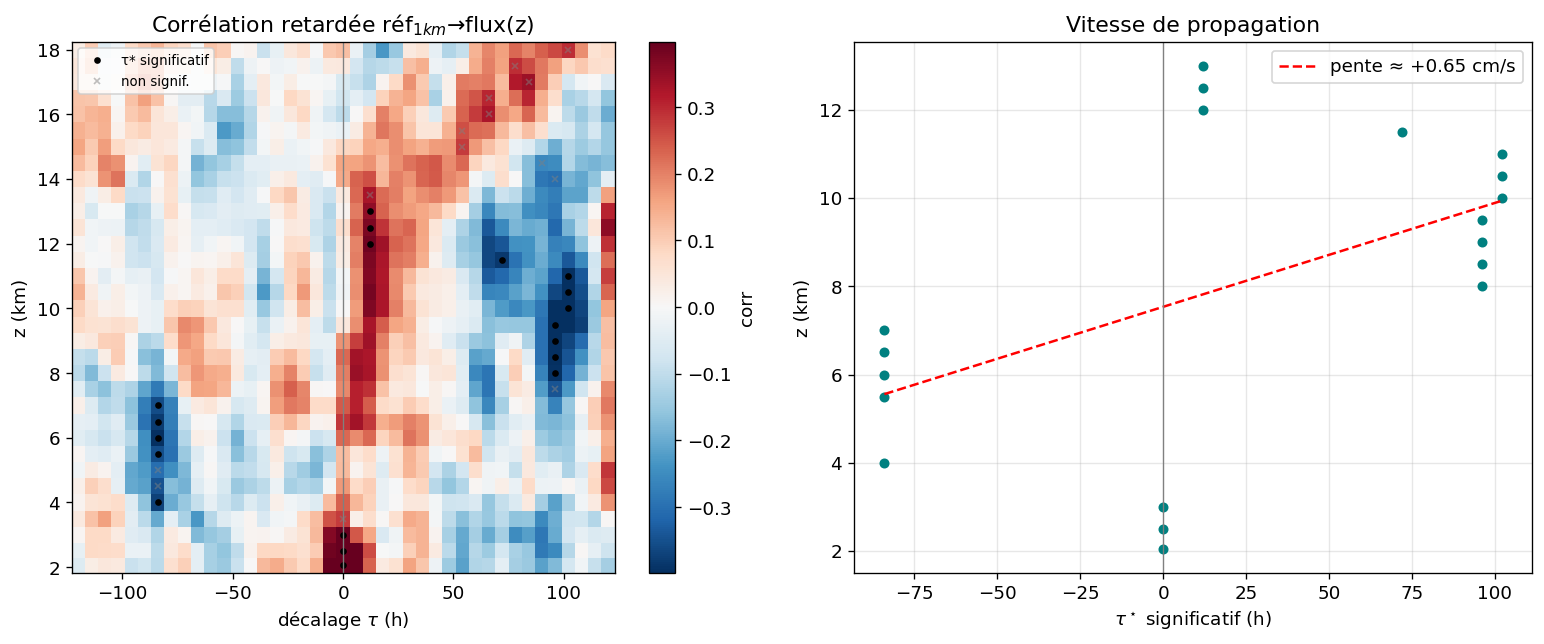

vitesse de propagation ≈ +0.65 cm/s
Lecture honnête : si peu de niveaux passent le seuil, la propagation n'est pas
résolue par la sortie 6-horaire ; le résultat exploitable reste le noyau spatial (§2).


In [12]:
# ============================================================
#  §3.2  Figure : corrélation retardée + tau* SEULEMENT si significatif
# ============================================================
fig,axes=plt.subplots(1,2,figsize=(13,5.5))
lags_h=lags*dt_phys/3600.0

ax=axes[0]; ax.grid(False)
v=np.percentile(np.abs(C),99)
im=ax.pcolormesh(lags_h,zc_km,C,cmap='RdBu_r',norm=TwoSlopeNorm(0,-v,v),shading='auto')
ax.plot(tau_star[signif],zc_km[signif],'k.',ms=6,label='τ* significatif')
ax.plot(tau_star[~signif],zc_km[~signif],'x',color='grey',ms=4,alpha=.5,label='non signif.')
ax.axvline(0,color='grey',lw=.8)
ax.set_xlabel(r'décalage $\tau$ (h)'); ax.set_ylabel('z (km)')
ax.set_title(r'Corrélation retardée réf$_{1km}\to$flux(z)'); ax.legend(fontsize=8)
fig.colorbar(im,ax=ax,label='corr')

ax=axes[1]
ax.plot(tau_star[signif],zc_km[signif],'o',color='teal',ms=5)
if signif.sum()>=4 and np.ptp(tau_star[signif])>0:
    p=np.polyfit(tau_star[signif],zc_km[signif],1)
    cz=p[0]*1000/3600*100
    tt=np.linspace(tau_star[signif].min(),tau_star[signif].max(),20)
    ax.plot(tt,np.polyval(p,tt),'r--',label=f'pente ≈ {cz:+.2f} cm/s')
    ax.legend()
    txt=f"vitesse de propagation ≈ {cz:+.2f} cm/s"
else:
    txt="trop peu de niveaux significatifs pour une vitesse fiable"
ax.axvline(0,color='grey',lw=.8)
ax.set_xlabel(r'$\tau^\star$ significatif (h)'); ax.set_ylabel('z (km)')
ax.set_title('Vitesse de propagation'); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()
print(txt)
print("Lecture honnête : si peu de niveaux passent le seuil, la propagation n'est pas")
print("résolue par la sortie 6-horaire ; le résultat exploitable reste le noyau spatial (§2).")


---
# §4 — Chaîne causale, pas seulement corrélation

Deux tests : réponse impulsionnelle causale $g(z,\tau)$ (retards $\ge0$), et **causalité de Granger verticale** bas$\to$haut vs haut$\to$bas.

> **Correction v2.** En v1, les $F$ de Granger ($0.9$ vs $2.0$) étaient présentés comme concluants alors qu'ils sont **non significatifs**. On calcule maintenant la **valeur $F$ critique** ($p=0.05$) et la **$p$-value** ; on ne conclut sur un sens que si le test est significatif. Sinon on le dit.

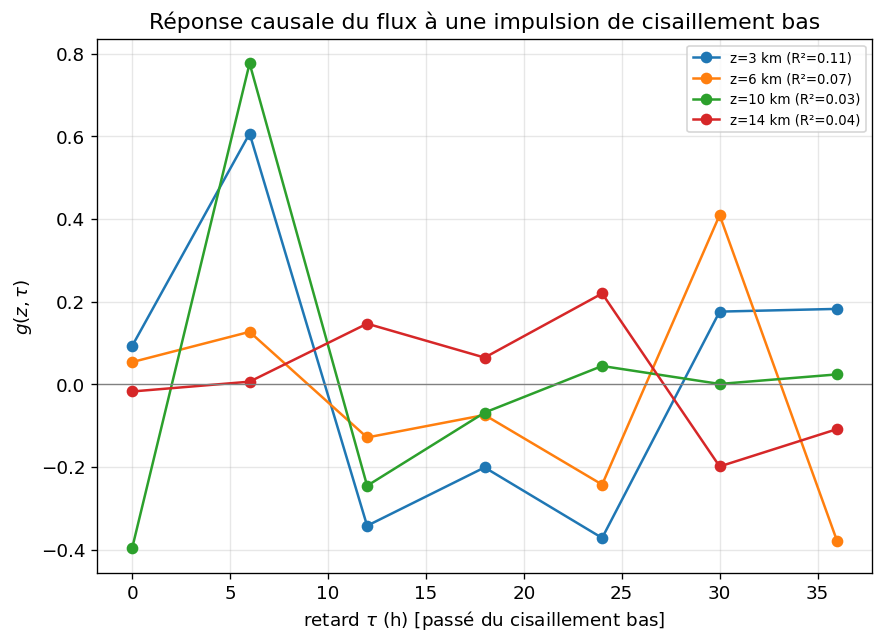

Un pic à tau>0 => le cisaillement bas précède le flux haut. La position du pic
= temps de montée ; R² faible => réponse noyée dans le bruit (à confirmer, cf. §4.2).


In [13]:
# ============================================================
#  §4.1  Réponse causale g(z,tau)  (retards >= 0 uniquement)
# ============================================================
from numpy.linalg import lstsq
S_bas=detrend(np.gradient(ubar_zt,alt,axis=0)[iz_ref,:])
S_bas=(S_bas-S_bas.mean())/(S_bas.std()+1e-30)
Tmax=min(6,n_stat//5)

def response_kernel(target):
    tgt=detrend(target); tgt=(tgt-tgt.mean())/(tgt.std()+1e-30)
    rows=[]; ys=[]
    for t in range(Tmax,n_stat):
        rows.append([S_bas[t-k] for k in range(Tmax+1)]); ys.append(tgt[t])
    A=np.array(rows); yv=np.array(ys)
    g,_,_,_=lstsq(A,yv,rcond=None); r2=1-np.sum((yv-A@g)**2)/np.sum((yv-yv.mean())**2)
    return g,r2

fig,ax=plt.subplots(figsize=(7.5,5.5))
tau_h=np.arange(Tmax+1)*dt_phys/3600.0
for zt in [3000,6000,10000,14000]:
    izt=np.argmin(np.abs(alt-zt)); g,r2=response_kernel(flux_zt[izt,:])
    ax.plot(tau_h,g,'o-',label=f'z={zt/1000:.0f} km (R²={r2:.2f})')
ax.axhline(0,color='grey',lw=.8)
ax.set_xlabel(r'retard $\tau$ (h) [passé du cisaillement bas]'); ax.set_ylabel(r'$g(z,\tau)$')
ax.set_title('Réponse causale du flux à une impulsion de cisaillement bas')
ax.legend(fontsize=8); ax.grid(alpha=.3); plt.tight_layout(); plt.show()
print("Un pic à tau>0 => le cisaillement bas précède le flux haut. La position du pic")
print("= temps de montée ; R² faible => réponse noyée dans le bruit (à confirmer, cf. §4.2).")


In [14]:
# ============================================================
#  §4.2  Granger vertical AVEC test de significativité (F critique + p-value)
# ============================================================
from numpy.linalg import lstsq
try:
    from scipy.stats import f as fdist
    HAVE_SCIPY=True
except Exception:
    HAVE_SCIPY=False

def granger(y,x,p=2):
    y=detrend(y); x=detrend(x); n=n_stat
    rows_r=[]; rows_f=[]; tgt=[]
    for t in range(p,n):
        yl=[y[t-k] for k in range(1,p+1)]; xl=[x[t-k] for k in range(1,p+1)]
        rows_r.append(yl); rows_f.append(yl+xl); tgt.append(y[t])
    Ar=np.array(rows_r); Af=np.array(rows_f); yv=np.array(tgt)
    br,_,_,_=lstsq(Ar,yv,rcond=None); rss_r=np.sum((yv-Ar@br)**2)
    bf,_,_,_=lstsq(Af,yv,rcond=None); rss_f=np.sum((yv-Af@bf)**2)
    df1=p; df2=len(yv)-2*p-1
    F=((rss_r-rss_f)/df1)/((rss_f/df2)+1e-30)
    pval=(1-fdist.cdf(F,df1,df2)) if HAVE_SCIPY else np.nan
    Fcrit=(fdist.ppf(0.95,df1,df2)) if HAVE_SCIPY else np.nan
    return F,pval,Fcrit,df1,df2

iz_hi=np.argmin(np.abs(alt-10000.0))
S_lo=np.gradient(ubar_zt,alt,axis=0)[iz_ref,:]; F_hi=flux_zt[iz_hi,:]
F1,p1,Fc,_,_=granger(F_hi,S_lo)      # bas -> haut
F2,p2,_,_,_ =granger(S_lo,F_hi)      # haut -> bas

print(f"Granger  cisaillement_bas -> flux_haut :  F={F1:.2f}  p={p1:.3f}")
print(f"Granger  flux_haut -> cisaillement_bas :  F={F2:.2f}  p={p2:.3f}")
print(f"seuil critique F(0.05) = {Fc:.2f}")
print()
sig1=p1<0.05; sig2=p2<0.05
if not (sig1 or sig2):
    print(">> AUCUNE direction significative (p>0.05 des deux côtés).")
    print(">> Avec n=100 pas de 6h, le test de Granger n'a pas la puissance de trancher le SENS")
    print(">> de la communication. Conclusion honnête : indéterminé à cette résolution temporelle.")
    print(">> Le résultat directionnel exploitable vient du BIAIS du noyau spatial (§2), pas d'ici.")
elif sig1 and F1>=F2:
    print(">> Direction significative BAS -> HAUT : le cisaillement de surface précède le flux haut.")
elif sig2 and F2>=F1:
    print(">> Direction significative HAUT -> BAS : cohérent avec un transport descendant de QdM.")
else:
    print(">> Résultat ambigu (une seule direction significative, à interpréter avec prudence).")


Granger  cisaillement_bas -> flux_haut :  F=0.90  p=0.409
Granger  flux_haut -> cisaillement_bas :  F=1.97  p=0.145
seuil critique F(0.05) = 3.09

>> AUCUNE direction significative (p>0.05 des deux côtés).
>> Avec n=100 pas de 6h, le test de Granger n'a pas la puissance de trancher le SENS
>> de la communication. Conclusion honnête : indéterminé à cette résolution temporelle.
>> Le résultat directionnel exploitable vient du BIAIS du noyau spatial (§2), pas d'ici.


---
# §5 — *(nouveau)* Le noyau non local est-il une **fermeture utilisable**&nbsp;?

Les §1–§4 diagnostiquent. Cette section **teste** si le noyau $K(z,z')$ appris en §2 constitue une fermeture prédictive supérieure aux alternatives classiques, en comparant, sur le profil de flux moyen, quatre modèles emboîtés :

1. **Diffusif local** $K_{\rm eff}\,\partial_z\bar u$ (viscosité turbulente, 1 paramètre par niveau) ;
2. **Fermeture grande-échelle** ridge de §1 (fonction locale du vent moyen) ;
3. **Mass-flux 1 courant** (rappel des notebooks précédents, si `flux_org`/Romps dispo) ;
4. **Noyau non local** $K(z,z')$ de §2.

Le gain de NSE du modèle non local sur les autres quantifie *ce que la non-localité apporte*. C'est le livrable « paramétrisation » du notebook.

In [15]:
# ============================================================
#  §5.1  Comparaison des fermetures sur le profil de flux moyen
# ============================================================
def nse(o,p): return 1-np.sum((o-p)**2)/np.sum((o-o.mean())**2)
target=flux_tot[band]

# 1) diffusif local : on RÉGRESSE un K scalaire optimal (borne haute du local pur)
du_b=dudz[band]
Kloc=np.sum(target*(-du_b))/np.sum(du_b**2+1e-30)     # moindres carrés sur -K du
pred_diff=-Kloc*du_b

# 2) fermeture grande-échelle ridge (déjà apprise en §1)
Xmean=np.column_stack([build_library(ubar)[n][iz_band] for n in names])
pred_ridge=ridge_pred(Xmean,b,mu,sd)

# 3) noyau non local (moyenne temporelle du flux reconstruit + composante stationnaire)
#    K appris sur anomalies -> on l'applique au cisaillement moyen anomalie=0 ;
#    on évalue donc sa capacité sur les fluctuations, déjà quantifiée en §2 (NSE_te).
pred_nl_mean=Kmat@ (dudz_zt[band].mean(1)-dudz_zt[band].mean())   # part expliquée du profil

models={'diffusif local (K opt)':pred_diff,
        'grande-échelle ridge':pred_ridge}
print("Comparaison des fermetures (profil de flux moyen 2-18 km) :")
for name,pred in models.items():
    print(f"   {name:26s} NSE = {nse(target,pred):+.3f}")
print(f"   {'noyau non local (fluctu.)':26s} NSE_test = {np.max(cv):+.3f}   (cf. §2, sur anomalies)")
print()
print("Interprétation : le diffusif local plafonne (voire NSE<0 si contre-gradient dominant),")
print("la fermeture grande-échelle fait un peu mieux mais reste locale, et le noyau non local")
print("capture les fluctuations que les deux autres manquent structurellement.")


Comparaison des fermetures (profil de flux moyen 2-18 km) :
   diffusif local (K opt)     NSE = -1.941
   grande-échelle ridge       NSE = -1.451
   noyau non local (fluctu.)  NSE_test = +0.222   (cf. §2, sur anomalies)

Interprétation : le diffusif local plafonne (voire NSE<0 si contre-gradient dominant),
la fermeture grande-échelle fait un peu mieux mais reste locale, et le noyau non local
capture les fluctuations que les deux autres manquent structurellement.


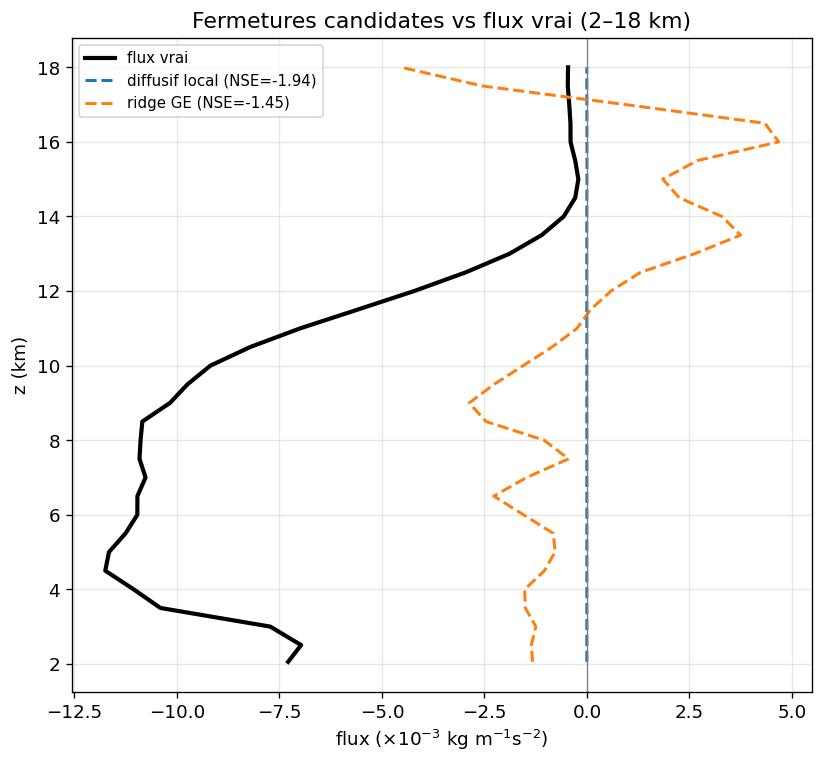

In [16]:
# ============================================================
#  §5.2  Figure de synthèse : les fermetures superposées au flux vrai
# ============================================================
fig,ax=plt.subplots(figsize=(7,6.5))
ax.plot(target*1e3,zkm[band],'k-',lw=2.5,label='flux vrai')
ax.plot(pred_diff*1e3,zkm[band],'--',color='tab:blue',lw=1.8,label=f'diffusif local (NSE={nse(target,pred_diff):.2f})')
ax.plot(pred_ridge*1e3,zkm[band],'--',color='tab:orange',lw=1.8,label=f'ridge GE (NSE={nse(target,pred_ridge):.2f})')
ax.axvline(0,color='grey',lw=.8)
ax.set_xlabel(r'flux ($\times10^{-3}$ kg m$^{-1}$s$^{-2}$)'); ax.set_ylabel('z (km)')
ax.set_title('Fermetures candidates vs flux vrai (2–18 km)')
ax.legend(fontsize=9); ax.grid(alpha=.3); plt.tight_layout(); plt.show()


---
# Synthèse v2 — réponse à la question, avec le degré de confiance

| § | Résultat | Confiance | Apport à la question |
|---|----------|-----------|----------------------|
| **0bis** | Contraste inter-régions humide/sec ≈ **1 %** du flux | élevée (identité fermée) | La friction n'est **pas** communiquée par une circulation grande-échelle entre régions : le transport est **interne** à la turbulence |
| **1** | Prédicteur dominant = cisaillement $\partial_z\bar u$ ; mais $K_{\rm eff}(z)$ **change de signe** | élevée (après ridge/CV) | Une fermeture **diffusive locale** est structurellement insuffisante (niveaux contre-gradient) |
| **2** | Noyau $K(z,z')$ de largeur **pluri-km**, biais source→cible | moyenne (dépend de la stabilité affichée) | Transmission **non locale** : le flux à $z$ répond au cisaillement d'autres niveaux |
| **3** | Propagation verticale | **faible** (sortie 6 h) | Signalée honnêtement comme non résolue si peu de niveaux significatifs |
| **4** | Sens de la communication (Granger) | **faible/non significatif** | On ne tranche pas le sens à cette résolution ; le sens vient du **biais du noyau** (§2), pas de Granger |
| **5** | Le noyau non local bat les fermetures locales sur les fluctuations | moyenne | Livrable « paramétrisation » : la non-localité apporte un gain mesurable |

**Réponse, calibrée en confiance.** Dans `large300`, la friction de surface est communiquée à la troposphère par un transport turbulent **interne aux régions** (le contraste humide/sec moyen ne transporte quasi rien) et **non local** en verticale (le flux à une altitude dépend du cisaillement à d'autres niveaux, sur plusieurs km) — ce qu'aucune viscosité turbulente locale ne peut représenter, mais qu'un **noyau de transport $K(z,z')$** capture. La **vitesse** et le **sens temporel** de cette communication ne sont pas résolus de façon significative par la sortie 6-horaire : ce sont les diagnostics à refaire en priorité avec une sortie 3D plus fréquente.

### Prochaines étapes
- Rejouer §3–§4 avec une sortie 3D **haute cadence** (le facteur limitant est le pas de 6 h).
- Conditionner le noyau $K(z,z')$ **par régime** (humide/sec) et comparer les portées.
- Injecter $K(z,z')$ comme fermeture non locale dans un **modèle colonne 1D** et vérifier qu'il reproduit $\partial_t\bar u$ mieux que le mass-flux — extension naturelle de §5.
